# Simple Bell State on Real IBM Backend

## Imports

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from matplotlib import pyplot as plt

## IBM Runtime Service

In [2]:
service = QiskitRuntimeService()

## Setting Backend With Least Busy and NO Simulator

In [3]:
backend = service.least_busy(simulator=False, operational=True)
print(f"Trageting Backend: {backend.name}")
print("Backend version:", backend.version)
print("Number of qubits:", backend.num_qubits)

Trageting Backend: ibm_fez
Backend version: 2
Number of qubits: 156


## Quantum Teleportation

In [4]:
def create_teleportation_circuit(initial_state_angle: float):
    """
    Create a Quantum teleportation circuit.

    Args: 
        initial_state_angle: The angle for Ry rotation to prepare the state to teleport 
    """

    # Create a Quantum Circuit with 3 qubits and 3 classical bits
    # qr[0]: state to teleport
    # qr[1]: Alice's entangled qubit
    # qr[2]: Bob's entangled qubit
    # cr[0,1]: Alice's measurement results.
    # cr[2]: Bob's final measurement for verification
    qc = QuantumCircuit(3, 3)

    # --- STEP 1: Prepare the state to be teleported (|psi>) ---
    # We'll use an Ry rotation to create a superposition state
    qc.ry(initial_state_angle, 0)
    qc.barrier()
    
    # --- STEP 2: Create Entangled Bell Pair (Qubits 1 and 2) ---
    # This pair is shared between Alice (q1) and Bob (q2)
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier()

    # --- STEP 3: Alice's Operations ---
    # Alice interacts her qubit (q0) with her half of the Bell pair (q1)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()

    # --- STEP 4: Measurement ---
    # Alice measures her two qubits
    qc.measure(0, 0)
    qc.measure(1, 1)
    qc.barrier()

    # --- STEP 5: Bob's Conditional Operations (Dynamic Circuit) ---
    # Bob applies gates to q2 based on Alice's measurement results.
    # In Qiskit 1.x, we use the 'if_test' for dynamic circuit logic.
    
    # If Alice's measurement of q1 (cr[1]) is 1, Bob applies an X gate
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(2)
        
    # If Alice's measurement of q0 (cr[0]) is 1, Bob applies a Z gate
    with qc.if_test((qc.clbits[0], 1)):
        qc.z(2)
    
    qc.barrier()

    # --- STEP 6: Verification ---
    # To verify teleportation, we apply the inverse of the initial state preparation.
    # If teleportation was successful, q2 should now be in the state we prepared in Step 1.
    # Applying the inverse should bring q2 back to the |0> state.
    qc.ry(-initial_state_angle, 2)
    qc.measure(2, 2)
    return qc

In [5]:
angle = np.pi / 4  # Example state
teleportation_circuit = create_teleportation_circuit(angle)

## Circuit Diagram

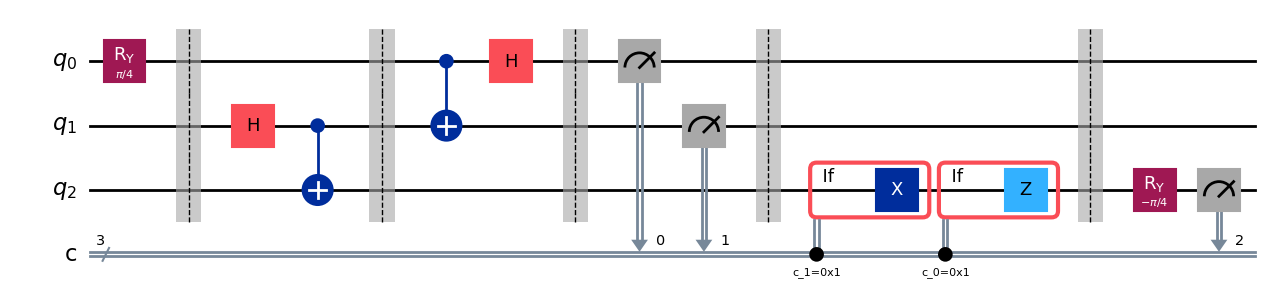

In [6]:
teleportation_circuit.draw(output='mpl', style='iqp')

## Pass Manager -> Converting qc circuit to ISA Circuit with Optimization

In [7]:
pm = generate_preset_pass_manager(backend=backend)

isa_circuit = pm.run(teleportation_circuit)

## ISA Circuit Diagram

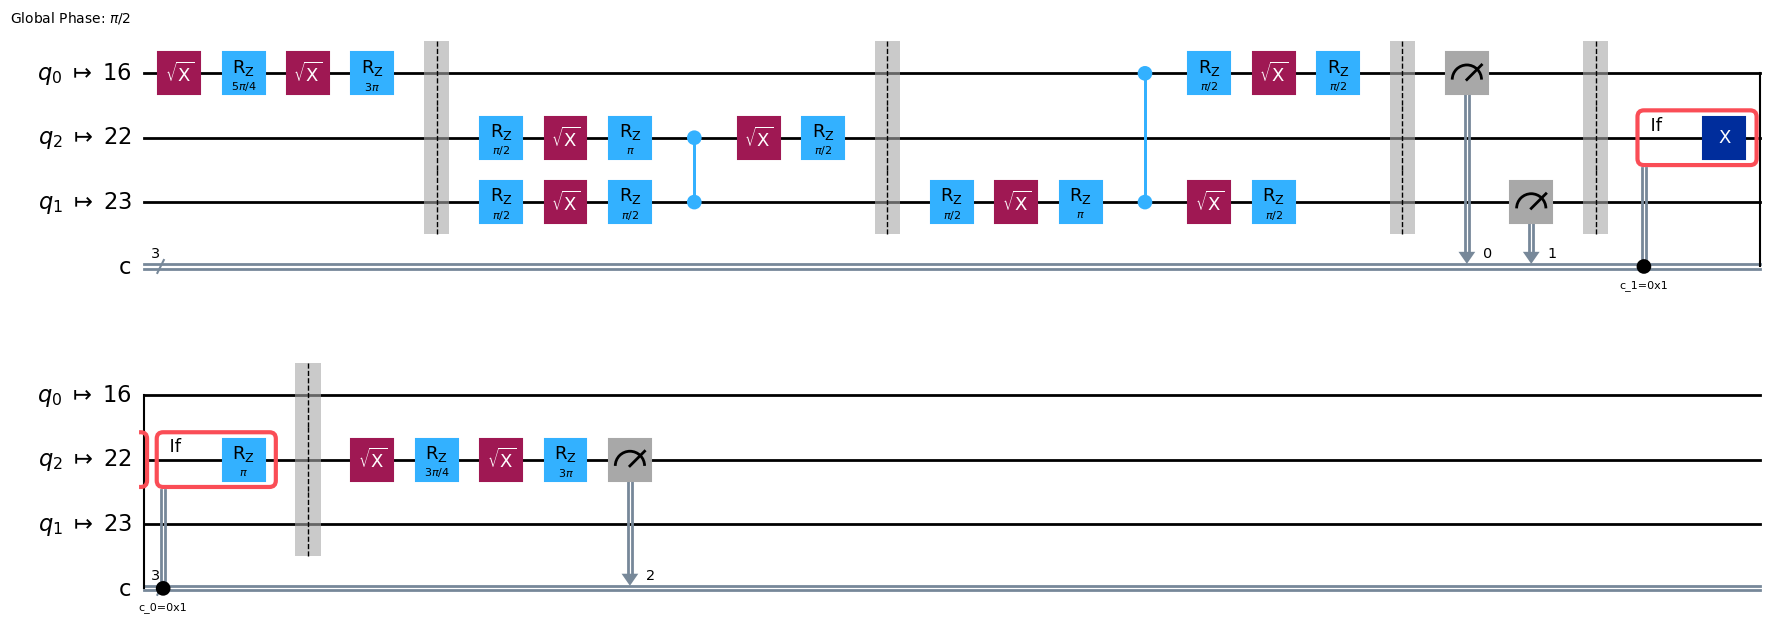

In [8]:
isa_circuit.draw(output='mpl', idle_wires=False)

## Running on Real IBM Backend

In [9]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

print(f"Submitting Job for {teleportation_circuit.name}...")
job = sampler.run([isa_circuit])
result = job.result()

Submitting Job for circuit-41...


KeyboardInterrupt: 

## Results

In [ ]:
# Access the data from the first job (index 0)
pub_result = result[0]

# Get the counts from the classical register (usually named 'meas' or 'c')
counts = pub_result.data.c.get_counts()
print("Measurement counts:", counts)

Measurement counts: {'001': 273, '000': 260, '011': 231, '110': 21, '010': 207, '111': 24, '101': 4, '100': 4}


In [ ]:
success_count = sum(count for bitstring, count in counts.items() if bitstring[0] == '0')
print(f"\nTeleportation Verification:")
print(f"Successful transfers (resulted in |0> after inverse): {success_count}")
print(f"Total shots: 1024")


Teleportation Verification:
Successful transfers (resulted in |0> after inverse): 971
Total shots: 1024
